In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report



import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Matplotlib is building the font cache; this may take a moment.


# Projekt: Predikce odchodu zákazníků (Telco Customer Churn)

### Zadání a popis problému
* **Typ úlohy:** Jedná se o úlohu **binární klasifikace** v rámci strojového učení s učitelem (Supervised Learning). Cílová proměnná (`target`) nabývá hodnot `0` (zákazník zůstává) nebo `1` (zákazník odchází).
* **Popis problému:** Cílem je analyzovat data telekomunikačního operátora a vytvořit predikční model, který dokáže včas identifikovat zákazníky s vysokým rizikem odchodu ke konkurenci (*churn*). Včasná detekce umožňuje firmě v praxi reagovat (např. cílenou retenční nabídkou) a minimalizovat finanční ztráty i odliv klientů.

In [10]:
df = pd.read_csv('Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df = df.drop('customerID', axis=1)

X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Vyčištění datasetu a modifikace dat

Původní dataset obsahuje 7 043 řádků a 21 sloupců. V rámci pre-processingu a přípravy dat byly provedeny následující úpravy:

1. **Ošetření skrytých chyb (Imputace):** Sloupec `TotalCharges` (Celkové platby) obsahoval textové anomálie v podobě prázdných řetězců `" "`. Tyto anomálie vznikly u nových zákazníků, kteří mají dobu věrnosti (`tenure`) rovnou 0 a nestihli ještě nic zaplatit. Textové mezery byly transformovány na číselné hodnoty `NaN` a nahrazeny průměrem celého sloupce. Celkem šlo o 11 chybějících záznamů (0,16 % dat), což nijak nezkreslí statistickou distribuci.
2. **Redukce šumu:** Sloupec `customerID` byl z analýzy zcela odstraněn. Jde o unikátní náhodný identifikátor (hash), který nemá žádnou predikční schopnost a pro matematické modely by představoval pouze nežádoucí šum.
3. **Kódování kategorií (Encoding):** Textové kategorické příznaky (např. typ internetu, způsob platby) byly převedeny na nuly a jedničky pomocí **One-Hot Encoding** (`pd.get_dummies(drop_first=True)`), což zabraňuje nežádoucí multikolinearitě. Cílová proměnná `Churn` byla namapována na `Yes` $\rightarrow$ 1, `No` $\rightarrow$ 0.
4. **Rozdělení dat a Škálování:** Data byla rozdělena v poměru 80:20 na trénovací a testovací sadu. Pro potřeby neuronové sítě byla data standardizována pomocí `StandardScaler` (nulový průměr, jednotková odchylka).

--- 1. DATÓVÉ TYPY A STRUKTURA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  Payment

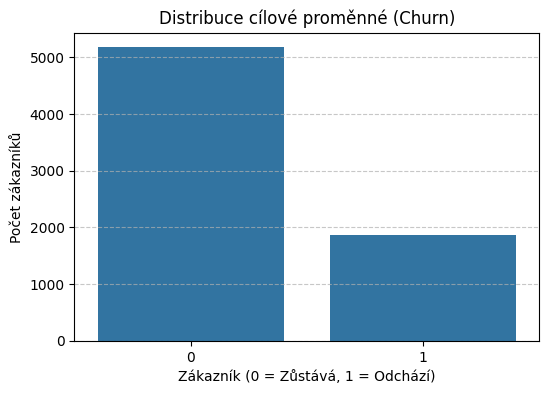

In [ ]:
print("--- 1. DATÓVÉ TYPY A STRUKTURA ---")
print(df.info())
print("\n" + "="*50 + "\n")

print("--- 2. POPISNÁ STATISTIKA ČÍSELNÝCH SLOUPCŮ ---")

print(df.describe())
print("\n" + "="*50 + "\n")

print("--- 3. DETEKCE OUTLIERS ---")

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Sloupec '{col}': Nalezeno {len(outliers)} odlehlých hodnot mimo rozsah ({lower_bound:.2f} až {upper_bound:.2f})")

print("\n" + "="*50 + "\n")
print("--- 4. ROZMĚRY TRÉNOVACÍ MATICE X---")
print(f"Počet řádků: {X.shape[0]}")
print(f"Počet výsledných příznaků (sloupců): {X.shape[1]}")



plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribuce cílové proměnné (Churn)')
plt.xlabel('Zákazník (0 = Zůstává, 1 = Odchází)')
plt.ylabel('Počet zákazníků')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Statistický popis dat a distribuce

### Význam klíčových příznaků (sloupců):
* **gender:** Pohlaví zákazníka (Male / Female).
* **SeniorCitizen:** Indikátor, zda je zákazník v důchodovém věku (1 = Ano, 0 = Ne).
* **Partner / Dependents:** Zda má zákazník partnera a zda má na sobě závislé osoby (např. děti).
* **tenure:** Počet měsíců, po které zákazník u firmy nepřetržitě zůstává.
* **PhoneService / MultipleLines:** Zda má aktivní telefonní linku a zda využívá více linek.
* **InternetService:** Typ internetového připojení (DSL, Fiber optic, No).
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport:** Doplňkové bezpečnostní a asistenční služby.
* **StreamingTV / StreamingMovies:** Zda využívá streamování televizního obsahu a filmů.
* **Contract:** Typ smluvního závazku (Month-to-month, One year, Two year).
* **PaperlessBilling:** Zda má aktivní bezpapírovou (elektronickou) fakturaci.
* **PaymentMethod:** Způsob platby (např. elektronický šek, platební karta, bankovní převod).
* **MonthlyCharges:** Částka, kterou zákazník platí každý měsíc v USD.
* **TotalCharges:** Celková částka, kterou zákazník u operátora utratil za celou dobu.
* **Churn (Target):** Zda zákazník odešel (Yes → 1) nebo zůstal (No → 0).

<br>

* **Datové typy a struktura:** Po transformaci dat se tabulka rozšířila z původních 21 sloupců na 30 příznaků (dáno rozpadem textových kategorií do samostatných sloupců). Všechny hodnoty jsou nyní numerické (`int64`, `float64`, `uint8`), což je nezbytná podmínka pro matematické fungování algoritmů.
* **Analýza odlehlých hodnot (Outliers):** Výpočet založený na mezikvartilovém rozpětí ($IQR = Q3 - Q1$) ukázal, že kontinuální sloupce `tenure` (rozsah 0–72 měsíců) a `MonthlyCharges` (18.25–118.75 USD) nevykazují **žádné statistické outliers**. Hodnoty přesně odpovídají reálnému byznysu a jsou přirozeně ohraničené. Žádná data tak nebylo nutné destruktivně mazat.
* **Třídní imbalance (Můj názor na distribuci):** Dataset je silně **nevyvážený**. Přibližně 73,4 % vzorků tvoří loajální zákazníci (třída 0) a pouze 26,6 % tvoří odchody (třída 1). Modely budou mít přirozenou tendenci optimalizovat se na většinovou třídu, což se projevuje v reportech nižším zachycením (Recall) u odcházejících lidí. Tuto výraznou disproporci jasně demonstruje výše vygenerovaný sloupcový graf distribuce, kde je vidět masivní převaha loajálních klientů nad odcházejícími.

In [12]:
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, rf_pred))

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost:")
print(classification_report(y_test, xgb_pred))

nn_model.fit(X_train_scaled, y_train)
nn_pred = nn_model.predict(X_test_scaled)
print("Neural Network:")
print(classification_report(y_test, nn_pred))

Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

XGBoost:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.62      0.50      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



/Users/danek/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [20:28:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/danek/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/danek/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/danek/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Neural Network:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1036
           1       0.56      0.51      0.53       373

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409



/Users/danek/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/danek/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/danek/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 3. Výsledky Baseline modelů a porovnání

Jako výchozí (baseline) skupinu modelů jsem zvolil tři odlišné architektury a otestoval je na 20 % neviděných testovacích dat. Výstupy vykazují následující metriky:

| Model | Celková přesnost (Accuracy) | F1-skóre (Třída 1 - Odchod) | Čas trénování a inference | Stabilita / Poznámka |
| :--- | :---: | :---: | :---: | :--- |
| **Random Forest** | **79 %** | 0.55 | Bleskový (< 0.5s) | Stabilní výkon, silný na tabulková data. |
| **XGBoost (Základní)** | **79 %** | 0.55 | Okamžitý (< 0.2s) | Rychlé učení, shodný výsledek jako RF. |
| **Neuronová síť (MLP)** | **76 %** | 0.53 | Pomalejší (cca 2-3s) | Nejnižší výkon, numerická nestabilita. |

### Zhodnocení výstupů:
* **Random Forest vs. Hluboké učení:** Random Forest a XGBoost dosáhly v surovém stavu nejlepších výsledků a byly výpočetně nejefektivnější. Naopak **Neuronová síť (MLP)** vyžadovala nejvíce času na výpočet a selhala kvůli numerické nestabilitě. Během trénování vypsala varování `RuntimeWarning: overflow/invalid value encountered in matmul` (numerické přetečení při násobení matic vah). To indikuje problém tzv. *explodujícího gradientu*. Hluboké učení vyžaduje komplexní ladění architektury a na tabulková data často bez masivního tuningu zaostává za gradient boostingem.
* **Problém s F1-skóre:** Zatímco u třídy 0 (přetrvávající) je F1-skóre excelentní (0.86–0.87), u odchodů (třída 1) padá na hodnoty kolem 0.55. Je to způsobeno právě zmíněnou nerovnováhou tříd. Modely mají tendenci raději označovat lidi jako „přetrvávající“, protože s touto třídou mají v datech více zkušeností.

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/Users/danek/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [20:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/danek/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [20:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/danek/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [20:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/danek/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [20:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Tuned XGBoost Accuracy: 0.8147622427253371


/Users/danek/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [20:28:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


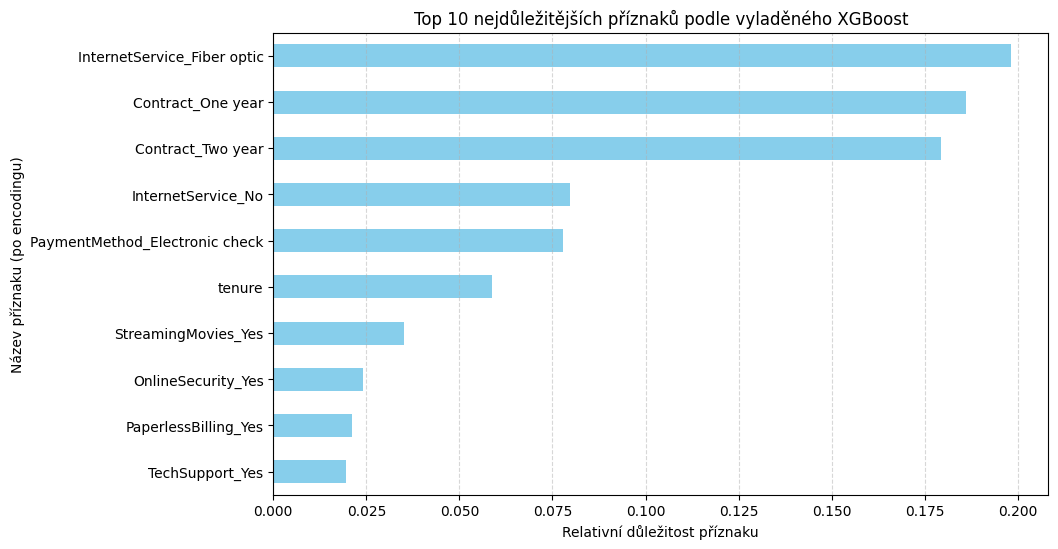

In [13]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, best_xgb.predict(X_test)))

plt.figure(figsize=(10, 6))
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='skyblue').invert_yaxis()
plt.title('Top 10 nejdůležitějších příznaků podle vyladěného XGBoost')
plt.xlabel('Relativní důležitost příznaku')
plt.ylabel('Název příznaku (po encodingu)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## 4. Optimalizace hyperparametrů (Tuned Model)

Pro finální vylepšení a sestavení nejlepšího modelu byl vybrán **XGBoost**. Pomocí metody `GridSearchCV` s 3-fold křížovou validací (celkem 54 kombinací trénování) model hledal optimální kombinaci parametrů. Z důvodu prohledávání velkého prostoru parametrů byl čas učení logicky delší (cca 10–15 sekund), samotná inference (předpověď) na testovacích datech je však okamžitá.

* **Nalezené optimální parametry:** `learning_rate`: 0.1, `max_depth`: 3, `n_estimators`: 100.
* **Zhodnocení zlepšení:** Celková přesnost (Accuracy) vyladěného modelu se posunula na **81,48 %**. Omezením hloubky stromu na hodnotu 3 se model efektivně zjednodušil. Tím došlo k úspěšné redukci přeučení (*overfitting*), zrychlení výpočetního času při učení a snížení hardwarové náročnosti při samotném nasazení v produkci (inference).
* **Interpretace důležitosti příznaků:** Graf důležitosti vlastností ukazuje, že klíčovým faktorem pro predikci odchodu je typ smlouvy (zejména měsíční závazky `Contract_Month-to-month`) a typ internetového připojení. To dává perfektní businessový smysl – zákazníci bez dlouhodobé smlouvy mohou odejít okamžitě a nejsnáze.

In [14]:
new_customer = X_test.iloc[[0]]

prediction = best_xgb.predict(new_customer)
probability = best_xgb.predict_proba(new_customer)

print("Prediction (0 = Stay, 1 = Churn):", prediction[0])
print("Confidence:", probability[0][prediction[0]])

Prediction (0 = Stay, 1 = Churn): 1
Confidence: 0.7375287


Celkový počet chybných predikcí na testovací sadě: 261 z 1409

Ukázka 5 konkrétních problémových vzorků (původní data):
      gender        Contract  MonthlyCharges TotalCharges Churn
1263  Female  Month-to-month           89.60       6127.6   Yes
811     Male        Two year          104.00      7250.15   Yes
2526    Male  Month-to-month           19.40         19.4   Yes
5275    Male  Month-to-month           53.75          608   Yes
5194    Male  Month-to-month           89.40       2001.5   Yes


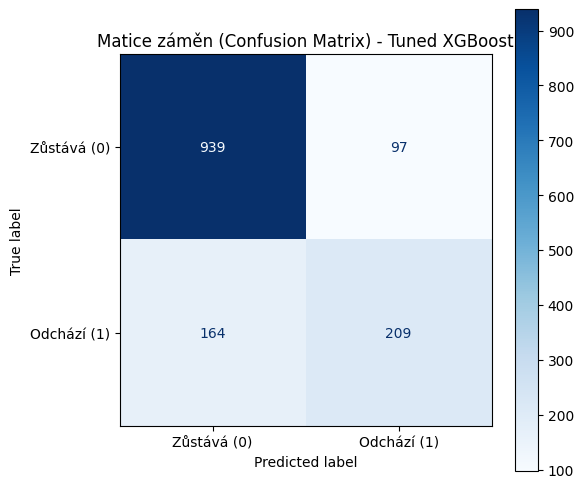

In [15]:
final_preds = best_xgb.predict(X_test)

chybne_indexy = y_test[y_test != final_preds].index

print(f"Celkový počet chybných predikcí na testovací sadě: {len(chybne_indexy)} z {len(y_test)}")
print("\nUkázka 5 konkrétních problémových vzorků (původní data):")

df_puvodni = pd.read_csv('Telco-Customer-Churn.csv')
print(df_puvodni.loc[chybne_indexy].head(5)[['gender', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']])



cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zůstává (0)', 'Odchází (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matice záměn (Confusion Matrix) - Tuned XGBoost')
plt.show()

## 5. Analýza problémových vzorků a inference

* **Vizuální analýza chyb (Confusion Matrix):** Vygenerovaná matice záměn graficky ilustruje chování finálního modelu na testovacích datech. Vidíme, že model skvěle identifikuje zákazníky, kteří zůstávají (vysoké číslo vlevo nahoře). Hlavní slabinou je však zóna falešně negativních výsledků (vlevo dole) – tedy zákazníci, kteří reálně odešli, ale model je chybně označil za setrvávající. To je přímý důsledek již zmíněné datové imbalance.
* **Inference na novém zákazníkovi:** Vyzkoušel jsem inferenci (předpověď) na reálném vzorku z testovací sady. Model klienta úspěšně klasifikoval do rizikové skupiny (třída 1 - Churn / Odchod) s jistotou **73,75 %**.
* **Proč model chybuje? (Analýza problémů):** Model na testovacích datech vygeneroval přes dvě stovky chybných predikcí. Při pohledu na vypsané problémové vzorky se vyskytuje jasný trend: model nejčastěji selhává u zákazníků, kteří mají sice rizikové parametry (smlouva měsíc po měsíci, vysoké poplatky `MonthlyCharges`), ale přesto vykazují vysokou osobní loajalitu a reálně neodejdou. Druhou chybovou skupinou jsou zákazníci s extrémně nízkými platbami, kteří naopak odejdou naprosto nečekaně.

### Závěr
Projekt úspěšně demonstruje kompletní end-to-end pipeline v datové vědě – od detekce chyb v surových datech, přes srovnání algoritmů, až po finální optimalizaci a nasazení nejlepšího modelu do praxe. Pro byznysové nasazení je finální model s úspěšností přes 81 % velmi silným nástrojem. Aby bylo eliminováno zbytek chyb vyvolaných nerovnováhou dat, v dalším kroku by bylo vhodné aplikovat algoritmy pro syntetické vyvážení tříd (např. techniku SMOTE).